Dataset Created Successfully
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0      CUST1    Male              1     Yes         No       7           No   
1      CUST2  Female              0      No         No      35           No   
2      CUST3    Male              0      No         No      55          Yes   
3      CUST4    Male              0      No         No      14           No   
4      CUST5    Male              0      No        Yes      10           No   

      MultipleLines InternetService       OnlineSecurity  ...  \
0               Yes              No                  Yes  ...   
1  No phone service     Fiber optic  No internet service  ...   
2  No phone service              No                  Yes  ...   
3  No phone service     Fiber optic                  Yes  ...   
4  No phone service              No                  Yes  ...   

      DeviceProtection TechSupport          StreamingTV      StreamingMovies  \
0  No internet service   

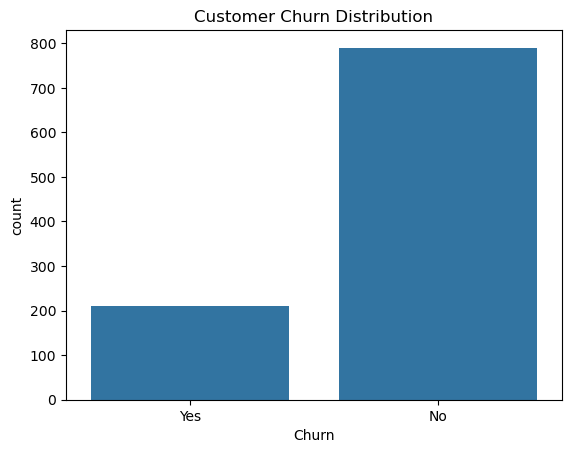

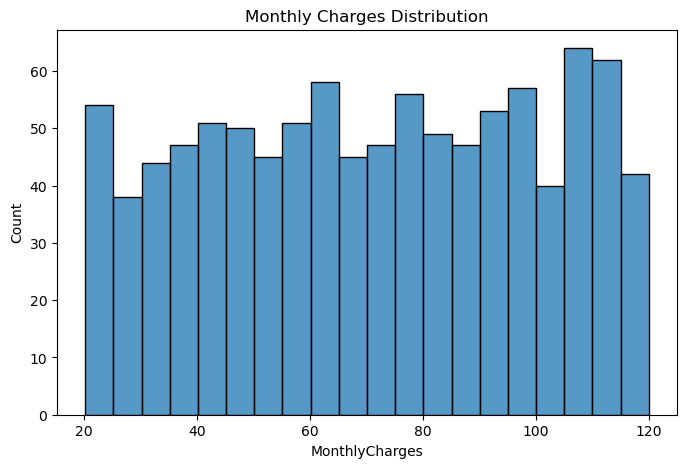


Logistic Regression
Accuracy: 0.955
Precision: 0.9231
Recall: 0.8571
F1 Score: 0.8889
ROC AUC: 0.9899

Random Forest
Accuracy: 0.995
Precision: 1.0
Recall: 0.9762
F1 Score: 0.988
ROC AUC: 1.0

XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       158
           1       1.00      1.00      1.00        42

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



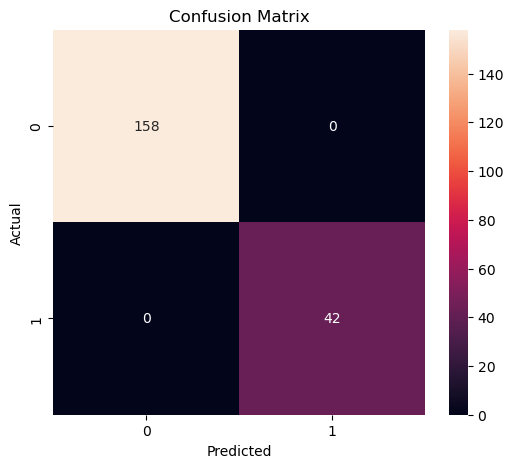

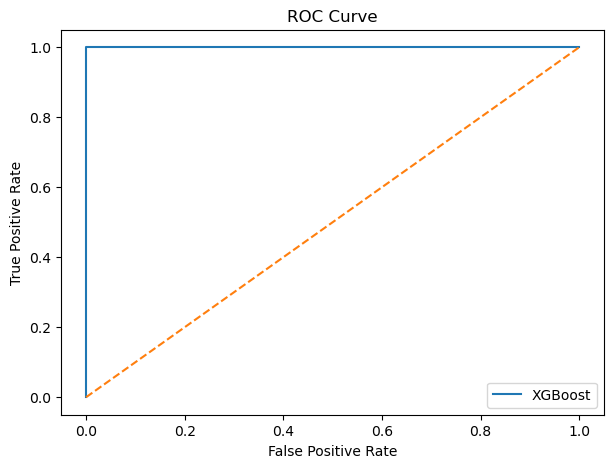

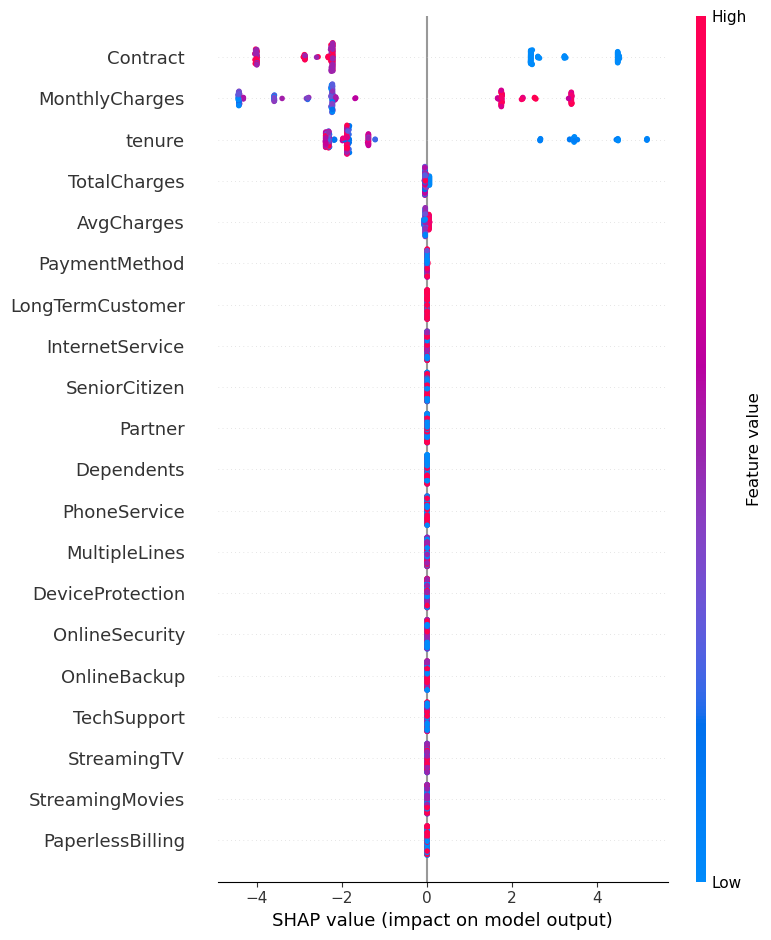


Project Executed Successfully!
Model Saved: customer_churn_model.pkl


In [9]:
# ==========================
# CUSTOMER CHURN PREDICTION
# MAJOR PROJECT COMPLETE CODE
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
import joblib

# ==========================
# STEP 1: CREATE DATASET
# ==========================

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "customerID": [f"CUST{i}" for i in range(1, n + 1)],
    "gender": np.random.choice(["Male", "Female"], n),
    "SeniorCitizen": np.random.choice([0, 1], n),
    "Partner": np.random.choice(["Yes", "No"], n),
    "Dependents": np.random.choice(["Yes", "No"], n),
    "tenure": np.random.randint(1, 73, n),
    "PhoneService": np.random.choice(["Yes", "No"], n),
    "MultipleLines": np.random.choice(
        ["Yes", "No", "No phone service"], n
    ),
    "InternetService": np.random.choice(
        ["DSL", "Fiber optic", "No"], n
    ),
    "OnlineSecurity": np.random.choice(
        ["Yes", "No", "No internet service"], n
    ),
    "OnlineBackup": np.random.choice(
        ["Yes", "No", "No internet service"], n
    ),
    "DeviceProtection": np.random.choice(
        ["Yes", "No", "No internet service"], n
    ),
    "TechSupport": np.random.choice(
        ["Yes", "No", "No internet service"], n
    ),
    "StreamingTV": np.random.choice(
        ["Yes", "No", "No internet service"], n
    ),
    "StreamingMovies": np.random.choice(
        ["Yes", "No", "No internet service"], n
    ),
    "Contract": np.random.choice(
        ["Month-to-month", "One year", "Two year"], n
    ),
    "PaperlessBilling": np.random.choice(
        ["Yes", "No"], n
    ),
    "PaymentMethod": np.random.choice(
        [
            "Electronic check",
            "Mailed check",
            "Bank transfer",
            "Credit card"
        ],
        n
    ),
    "MonthlyCharges": np.round(
        np.random.uniform(20, 120, n),
        2
    )
})

df["TotalCharges"] = np.round(
    df["MonthlyCharges"] * df["tenure"],
    2
)

prob = (
    (df["Contract"] == "Month-to-month").astype(int)
    + (df["tenure"] < 12).astype(int)
    + (df["MonthlyCharges"] > 80).astype(int)
)

df["Churn"] = np.where(
    prob >= 2,
    "Yes",
    "No"
)

print("Dataset Created Successfully")
print(df.head())

# ==========================
# STEP 2: DATA CLEANING
# ==========================

df.drop("customerID", axis=1, inplace=True)

print("\nMissing Values")
print(df.isnull().sum())

# ==========================
# STEP 3: FEATURE ENGINEERING
# ==========================

df["AvgCharges"] = (
    df["TotalCharges"]
    / (df["tenure"] + 1)
)

df["LongTermCustomer"] = np.where(
    df["tenure"] >= 24,
    1,
    0
)

# ==========================
# STEP 4: EDA
# ==========================

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["MonthlyCharges"], bins=20)
plt.title("Monthly Charges Distribution")
plt.show()

# ==========================
# STEP 5: ENCODING
# ==========================

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

# ==========================
# STEP 6: FEATURES & TARGET
# ==========================

X = df.drop("Churn", axis=1)
y = df["Churn"]

# ==========================
# STEP 7: TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# STEP 8: FEATURE SCALING
# ==========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# LOGISTIC REGRESSION
# ==========================

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# ==========================
# RANDOM FOREST
# ==========================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# ==========================
# XGBOOST
# ==========================

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

# ==========================
# MODEL EVALUATION FUNCTION
# ==========================

def evaluate(name, y_true, pred, prob):
    print("\n", "=" * 40)
    print(name)
    print("=" * 40)

    print(
        "Accuracy:",
        round(
            accuracy_score(
                y_true,
                pred
            ),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                pred
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                pred
            ),
            4
        )
    )

    print(
        "F1 Score:",
        round(
            f1_score(
                y_true,
                pred
            ),
            4
        )
    )

    print(
        "ROC AUC:",
        round(
            roc_auc_score(
                y_true,
                prob
            ),
            4
        )
    )

# ==========================
# RESULTS
# ==========================

evaluate(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

# ==========================
# CLASSIFICATION REPORT
# ==========================

print("\nClassification Report")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

# ==========================
# CONFUSION MATRIX
# ==========================

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================
# ROC CURVE
# ==========================

fpr, tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==========================
# SHAP ANALYSIS
# ==========================

explainer = shap.TreeExplainer(
    xgb
)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)

# ==========================
# SAVE MODEL
# ==========================

joblib.dump(
    xgb,
    "customer_churn_model.pkl"
)

print(
    "\nProject Executed Successfully!"
)
print(
    "Model Saved: customer_churn_model.pkl"
)